# Day 4: Fund Performance Analytics

## Objective

The objective of this notebook is to evaluate the performance of mutual funds using various financial metrics such as annual returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

The analysis also compares fund performance with benchmark indices and ranks funds based on multiple performance indicators to identify the best and worst performing schemes.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
plt.style.use("ggplot")

In [6]:
# Load all required datasets

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history.csv")
scheme_performance = pd.read_csv("../data/processed/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [7]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Benchmark: (8050, 3)


In [8]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [9]:
# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort by fund and date
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Calculate daily return for each fund
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

# View first few rows
nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [10]:
# Check summary statistics of daily returns
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [11]:
# Count missing values in daily_return
nav_history["daily_return"].isna().sum()

np.int64(40)

In [12]:
# Save the daily returns file
nav_history.to_csv(
    "../outputs/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully!")

returns_computed.csv saved successfully!


In [13]:
# Check the date range in NAV history
print(nav_history["date"].min())
print(nav_history["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [14]:
print(nav_history["amfi_code"].nunique())

40


In [15]:
# Calculate CAGR for each mutual fund

cagr_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    start_date = df.iloc[0]["date"]
    end_date = df.iloc[-1]["date"]

    years = (end_date - start_date).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append({
        "amfi_code": fund,
        "start_date": start_date,
        "end_date": end_date,
        "years": round(years, 2),
        "CAGR (%)": round(cagr, 2)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,start_date,end_date,years,CAGR (%)
0,100016,2022-01-03,2026-05-29,4.4,2.64
1,100025,2022-01-03,2026-05-29,4.4,4.46
2,100033,2022-01-03,2026-05-29,4.4,30.12
3,101206,2022-01-03,2026-05-29,4.4,23.54
4,101207,2022-01-03,2026-05-29,4.4,7.94


In [16]:
cagr_df.to_csv("../outputs/cagr_report.csv", index=False)

print("cagr_report.csv saved successfully!")

cagr_report.csv saved successfully!


In [17]:
# Annual risk-free rate (6.5%)
risk_free_rate = 0.065

sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * np.sqrt(252)

        sharpe = (annual_return - risk_free_rate) / annual_volatility

        sharpe_results.append({
            "amfi_code": fund,
            "Annual Return": round(annual_return * 100, 2),
            "Annual Volatility": round(annual_volatility * 100, 2),
            "Sharpe Ratio": round(sharpe, 2)
        })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Annual Return,Annual Volatility,Sharpe Ratio
0,100016,3.57,14.55,-0.20
1,100025,4.29,3.91,-0.57
2,100033,27.21,18.94,1.09
3,101206,21.46,14.57,1.03
4,101207,10.70,25.80,0.16


In [18]:
sharpe_df.to_csv("../outputs/sharpe_values.csv", index=False)

print("sharpe_values.csv saved successfully!")

sharpe_values.csv saved successfully!


In [19]:
# Annual risk-free rate
risk_free_rate = 0.065

sortino_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund]

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        annual_return = returns.mean() * 252

        # Downside returns only
        downside_returns = returns[returns < 0]

        if len(downside_returns) > 0:

            downside_std = downside_returns.std() * np.sqrt(252)

            sortino = (annual_return - risk_free_rate) / downside_std

        else:
            sortino = np.nan

        sortino_results.append({
            "amfi_code": fund,
            "Annual Return": round(annual_return * 100, 2),
            "Downside Volatility": round(downside_std * 100, 2),
            "Sortino Ratio": round(sortino, 2)
        })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Annual Return,Downside Volatility,Sortino Ratio
0,100016,3.57,8.35,-0.35
1,100025,4.29,2.35,-0.94
2,100033,27.21,11.32,1.83
3,101206,21.46,8.32,1.80
4,101207,10.70,15.17,0.28


In [20]:
sortino_df.to_csv("../outputs/sortino_values.csv", index=False)

print("sortino_values.csv saved successfully!")

sortino_values.csv saved successfully!


In [21]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [22]:
# Convert date column to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort data
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate benchmark daily returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

# Display first 10 rows
benchmark.head(10)

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726
3455,2022-01-10,BSE_SMALLCAP,26476.06,0.006049
3456,2022-01-11,BSE_SMALLCAP,26462.96,-0.000495
3457,2022-01-12,BSE_SMALLCAP,26090.99,-0.014056
3458,2022-01-13,BSE_SMALLCAP,26085.36,-0.000216
3459,2022-01-14,BSE_SMALLCAP,26081.45,-0.000150


In [23]:
# Convert date column to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort data
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate benchmark daily returns
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

# Display first 10 rows
benchmark.head(10)

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726
3455,2022-01-10,BSE_SMALLCAP,26476.06,0.006049
3456,2022-01-11,BSE_SMALLCAP,26462.96,-0.000495
3457,2022-01-12,BSE_SMALLCAP,26090.99,-0.014056
3458,2022-01-13,BSE_SMALLCAP,26085.36,-0.000216
3459,2022-01-14,BSE_SMALLCAP,26081.45,-0.000150


In [24]:
# Merge fund returns with benchmark returns using date

merged_data = pd.merge(
    nav_history,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

# Remove missing values
merged_data = merged_data.dropna(subset=["daily_return", "benchmark_return"])

print(merged_data.head())

    amfi_code       date       nav  daily_return  benchmark_return
7      100016 2022-01-04  515.0971     -0.010306          0.019783
8      100016 2022-01-04  515.0971     -0.010306          0.001516
9      100016 2022-01-04  515.0971     -0.010306          0.000044
10     100016 2022-01-04  515.0971     -0.010306         -0.013540
11     100016 2022-01-04  515.0971     -0.010306          0.011253


In [25]:
print(merged_data.shape)

(321720, 5)


In [26]:
alpha_beta_results = []

for fund in merged_data["amfi_code"].unique():

    fund_data = merged_data[merged_data["amfi_code"] == fund]

    if len(fund_data) > 30:

        slope, intercept, r_value, p_value, std_err = stats.linregress(
            fund_data["benchmark_return"],
            fund_data["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append({
            "amfi_code": fund,
            "Alpha": round(alpha, 4),
            "Beta": round(beta, 4)
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.0350,0.0048
1,100025,0.0433,-0.0034
2,100033,0.2688,0.0241
3,101206,0.2147,-0.0001
4,101207,0.1102,-0.0236


In [28]:
alpha_beta_df.to_csv("../outputs/alpha_beta.csv", index=False)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [29]:
max_dd_results = []

for fund in nav_history["amfi_code"].unique():

    df = nav_history[nav_history["amfi_code"] == fund].copy()

    df = df.sort_values("date")

    # Running maximum NAV
    df["running_max"] = df["nav"].cummax()

    # Drawdown
    df["drawdown"] = (df["nav"] / df["running_max"]) - 1

    # Maximum drawdown
    max_dd = df["drawdown"].min()

    max_dd_results.append({
        "amfi_code": fund,
        "Maximum Drawdown (%)": round(max_dd * 100, 2)
    })

max_dd_df = pd.DataFrame(max_dd_results)

max_dd_df.head()

,amfi_code,Maximum Drawdown (%)
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [30]:
max_dd_df.to_csv("../outputs/max_drawdown.csv", index=False)

print("max_drawdown.csv saved successfully!")

max_drawdown.csv saved successfully!


In [31]:
fund_scorecard = (
    cagr_df[["amfi_code", "CAGR (%)"]]
    .merge(sharpe_df[["amfi_code", "Sharpe Ratio"]], on="amfi_code")
    .merge(sortino_df[["amfi_code", "Sortino Ratio"]], on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(max_dd_df, on="amfi_code")
)

fund_scorecard.head()

,amfi_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown (%)
0,100016,2.64,-0.20,-0.35,0.0350,0.0048,-24.73
1,100025,4.46,-0.57,-0.94,0.0433,-0.0034,-4.31
2,100033,30.12,1.09,1.83,0.2688,0.0241,-16.22
3,101206,23.54,1.03,1.80,0.2147,-0.0001,-11.29
4,101207,7.94,0.16,0.28,0.1102,-0.0236,-35.45


In [32]:
fund_scorecard.to_csv("../outputs/fund_scorecard.csv", index=False)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [33]:
# Rank funds based on CAGR

ranked_funds = fund_scorecard.sort_values(
    by="CAGR (%)",
    ascending=False
)

ranked_funds.head(10)

,amfi_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown (%)
25,120505,32.83,1.18,2.03,0.2951,-0.0175,-18.19
21,119598,32.42,0.95,1.68,0.3031,-0.0035,-28.71
39,149324,32.29,0.95,1.62,0.2958,0.0367,-31.17
36,148569,31.95,1.23,2.15,0.2808,0.0176,-16.40
34,148567,30.97,1.45,2.39,0.2691,0.0105,-11.27
30,120843,30.91,1.31,2.36,0.2732,-0.0044,-12.97
2,100033,30.12,1.09,1.83,0.2688,0.0241,-16.22
38,149323,29.58,1.13,1.88,0.2657,0.0013,-17.25
16,119094,28.21,1.00,1.70,0.2627,-0.0287,-20.96
19,119551,25.80,1.21,2.14,0.2345,-0.0252,-15.01


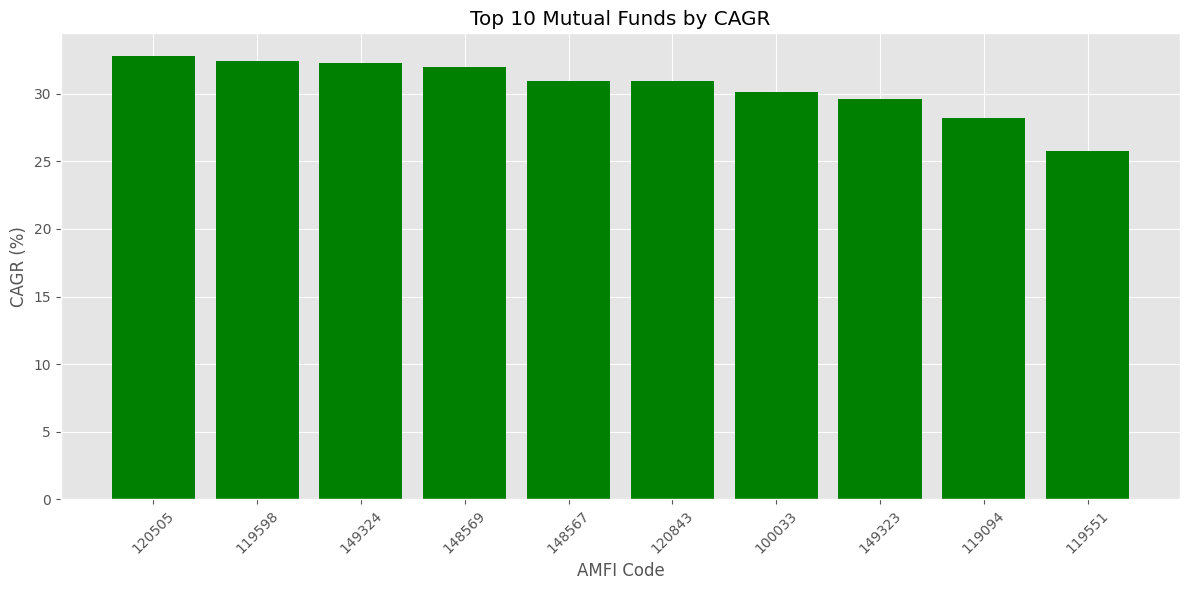

In [34]:
plt.figure(figsize=(12,6))

plt.bar(
    ranked_funds["amfi_code"].astype(str).head(10),
    ranked_funds["CAGR (%)"].head(10),
    color="green"
)

plt.title("Top 10 Mutual Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/top10_cagr.png")

plt.show()

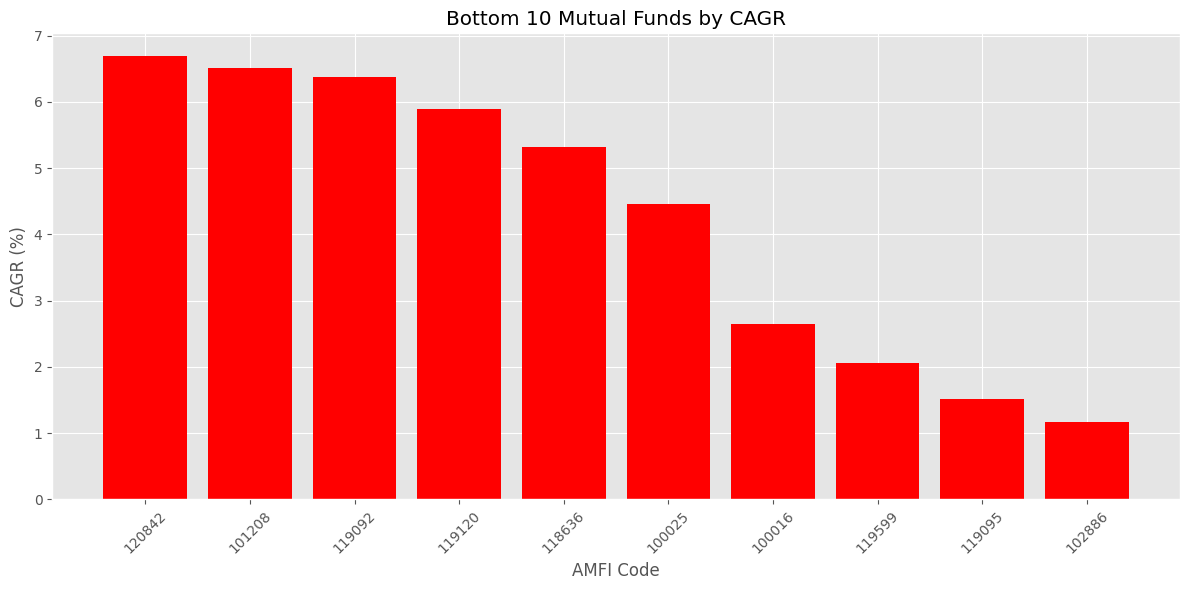

In [35]:
bottom_funds = ranked_funds.tail(10)

plt.figure(figsize=(12,6))

plt.bar(
    bottom_funds["amfi_code"].astype(str),
    bottom_funds["CAGR (%)"],
    color="red"
)

plt.title("Bottom 10 Mutual Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/bottom10_cagr.png")

plt.show()

# Conclusion

This notebook evaluates mutual fund performance using multiple financial metrics.

Metrics Calculated:
- Daily Return
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown

Outputs Generated:
- Fund Scorecard
- Top 10 Mutual Funds
- Bottom 10 Mutual Funds
- Performance Charts

The notebook can be extended further by adding rolling returns, volatility forecasting, and portfolio optimization.